In [28]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os,boto3
from io import StringIO
from dotenv import load_dotenv
load_dotenv("../secrets.env")


True

# Chargement des données

In [29]:
file_path = "..//Data//data_wip.xlsx"
df = pd.read_excel(file_path, sheet_name="Data_v2")


### Structure

In [30]:
# Informations
print("Nombre de colonnes : {}".format(df.shape[1]))
print()

print("Nombre de lignes : {}".format(df.shape[0]))
print()

print("Affichage du dataset : ")
display(df.head())
print()

print("Statistiques basiques : ")
data_desc = df.describe(include="all")
display(data_desc)
print()

print("Pourcentage de valeurs manquantes : ")
Nb_Lignes = df.shape[0]
for column in df.columns:
    Nb_Null = df[column].isnull().sum()
    if Nb_Null != 0 :
        Pct_val_Null = round((Nb_Null/Nb_Lignes)*100,2)
        print(f"Dans la colonne {column}, il y a {Nb_Null} NULL soit {Pct_val_Null}%")

print("Type des donnees")
display (df.dtypes)

Nombre de colonnes : 27

Nombre de lignes : 672

Affichage du dataset : 


,Code_Dpt,Departement,Region,annee,densite,pop_globale,tranche_age_0-24,tranche_age_25-59,tranche_age_60+,csp1_agriculteurs,...,nb_salaries_secteur_agricole,nb_salaries_secteur_industrie,nb_salaries_secteur_service,nbre_entreprises_agricole,nbre_entreprises_industrie,nbre_entreprises_service,Deblais_gravats,Dechets_verts,Encombrants,Materiaux_recyclables
0,01,Ain,Auvergne-Rhône-Alpes,2009,101.8,588857,188068,281744,119045,4017,...,5719,68343,141408,3092,6263,15605,37593,45013,34729,25405
1,02,Aisne,Hauts-de-France,2009,73.4,539547,170369,249910,119268,5250,...,9413,44128,129961,3720,3913,11215,24380,24539,31593,10542
2,03,Allier,Auvergne-Rhône-Alpes,2009,46.6,342559,86913,152570,103076,6019,...,7372,31537,92422,3325,3011,8474,14374,18612,11932,8564
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,2009,23.0,159510,43500,70222,45788,2136,...,3155,10803,44575,1473,2096,6415,11228,8280,9006,7327
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,2009,24.5,135883,37235,62716,35932,2214,...,2761,8607,46547,1333,1869,5980,8509,6121,7938,10344



Statistiques basiques : 


,Code_Dpt,Departement,Region,annee,densite,pop_globale,tranche_age_0-24,tranche_age_25-59,tranche_age_60+,csp1_agriculteurs,...,nb_salaries_secteur_agricole,nb_salaries_secteur_industrie,nb_salaries_secteur_service,nbre_entreprises_agricole,nbre_entreprises_industrie,nbre_entreprises_service,Deblais_gravats,Dechets_verts,Encombrants,Materiaux_recyclables
count,672,672,672,672.00000,672.000000,6.720000e+02,672.000000,6.720000e+02,672.000000,672.000000,...,672.000000,672.000000,6.720000e+02,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000
unique,96,96,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,01,Ain,Occitanie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7,7,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2015.00000,562.275595,6.680762e+05,200551.943452,3.013074e+05,166216.901786,4567.273810,...,7287.584821,52102.389881,2.112496e+05,3461.934524,5663.366071,17595.308036,38372.750000,41053.160714,33545.791667,21114.000000
std,NaN,NaN,NaN,4.00298,2437.639969,5.083613e+05,166511.953881,2.403171e+05,107206.487698,2454.689106,...,4548.299973,36910.410555,2.262971e+05,2060.443654,3166.412260,11510.375527,33298.025491,34178.927408,24013.880054,15591.703102
min,NaN,NaN,NaN,2009.00000,14.800000,7.648700e+04,19011.000000,3.177000e+04,21512.000000,95.000000,...,158.000000,5051.000000,2.284200e+04,73.000000,944.000000,2852.000000,1.000000,14.000000,557.000000,143.000000
25%,NaN,NaN,NaN,2011.00000,49.750000,2.980410e+05,82347.250000,1.277485e+05,85948.000000,3021.500000,...,4571.000000,24601.000000,7.534875e+04,2354.500000,3107.000000,8472.250000,14757.250000,15137.500000,15241.250000,9407.250000
50%,NaN,NaN,NaN,2015.00000,82.850000,5.374320e+05,159040.000000,2.368185e+05,140818.000000,4253.500000,...,6431.000000,44516.000000,1.487785e+05,3172.500000,4944.500000,14468.500000,29670.500000,31442.500000,28454.000000,16688.500000
75%,NaN,NaN,NaN,2019.00000,162.300000,8.691688e+05,260820.500000,3.895652e+05,221027.750000,5787.000000,...,9287.250000,69389.250000,2.563475e+05,4265.250000,7455.250000,23434.250000,50271.500000,57365.500000,43542.500000,28904.500000



Pourcentage de valeurs manquantes : 
Type des donnees


Code_Dpt                                      object
Departement                                   object
Region                                        object
annee                                          int64
densite                                      float64
pop_globale                                    int64
tranche_age_0-24                               int64
tranche_age_25-59                              int64
tranche_age_60+                                int64
csp1_agriculteurs                              int64
csp2_artisans_commercant_chef_entreprises      int64
csp3_cadres_professions_intellectuelles        int64
csp4_professions_intermediaires                int64
csp5_employes                                  int64
csp6_ouvriers                                  int64
csp7_retraites                                 int64
csp8_sans_activite                             int64
nb_salaries_secteur_agricole                   int64
nb_salaries_secteur_industrie                 

Les données du nombre d'entreprises sont manquantes sur l'exercice 2021.

# Partie 1 : Statistiques générales

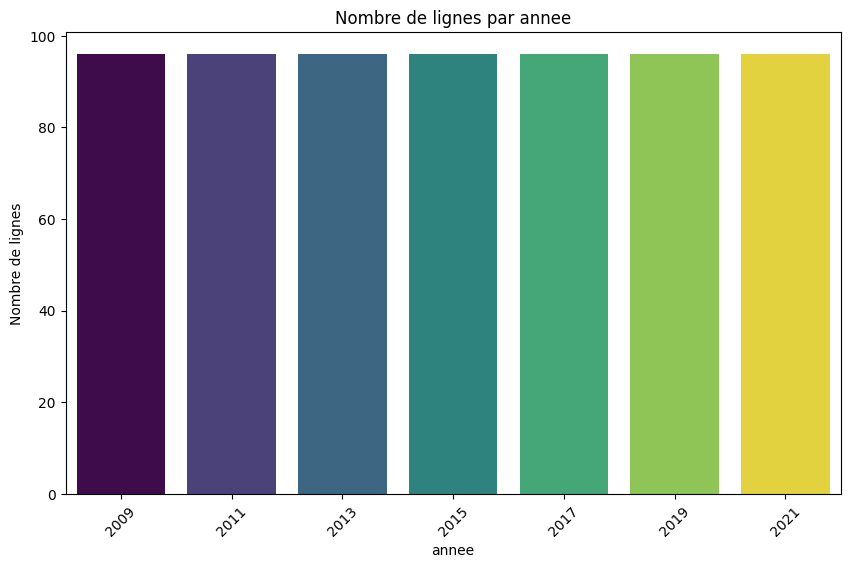

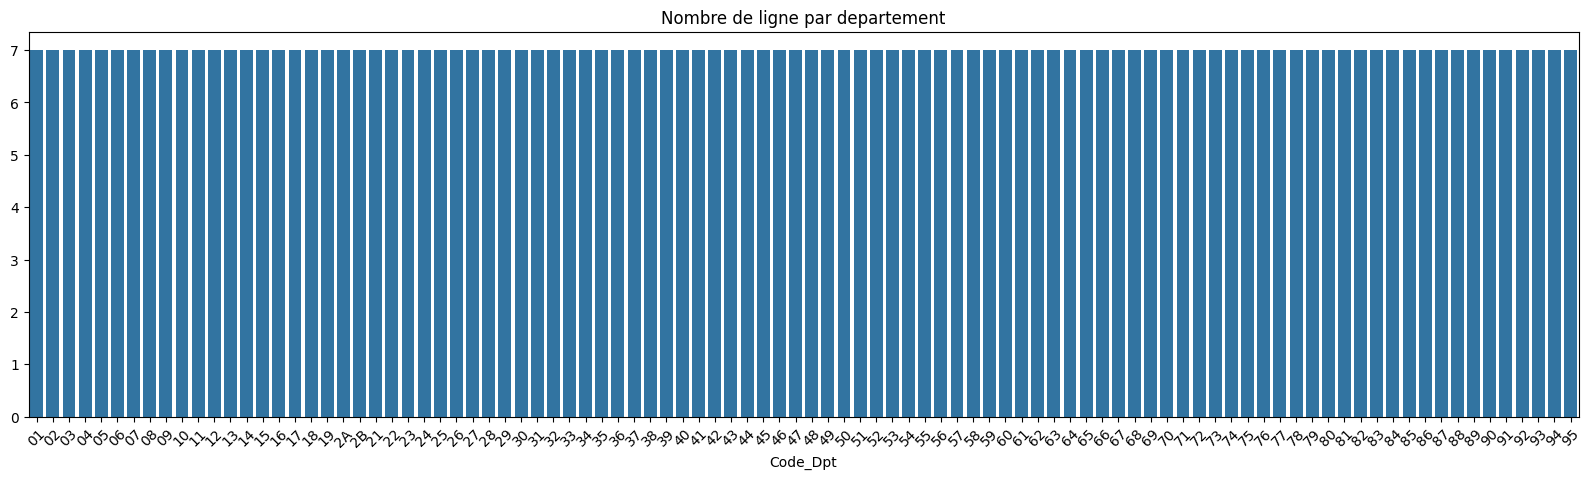

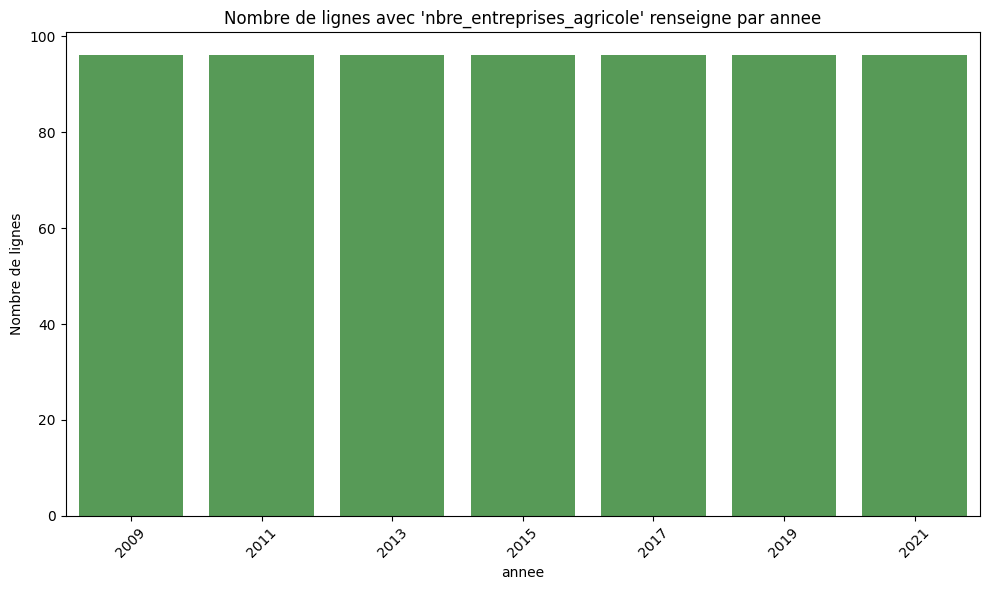

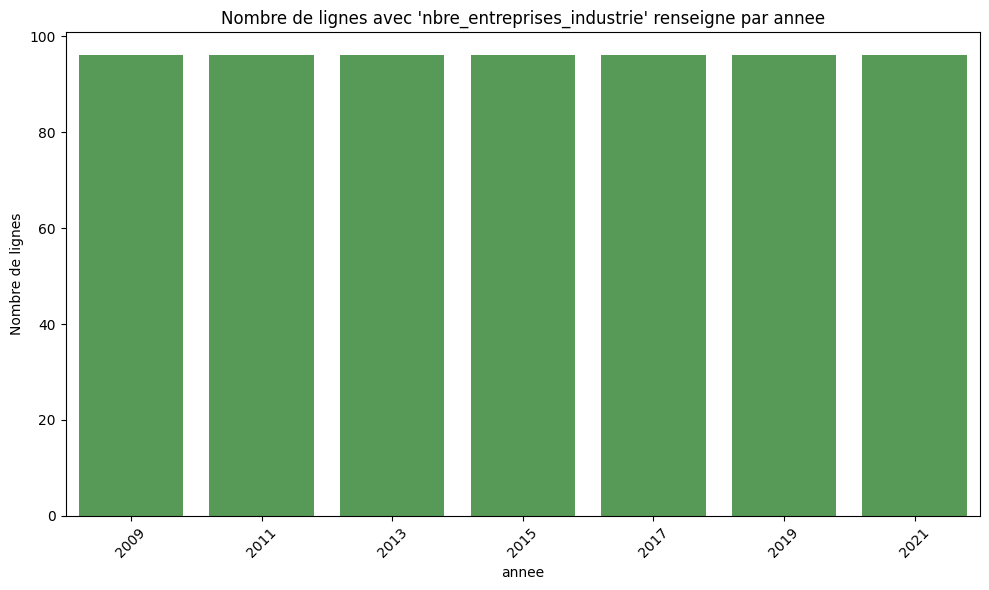

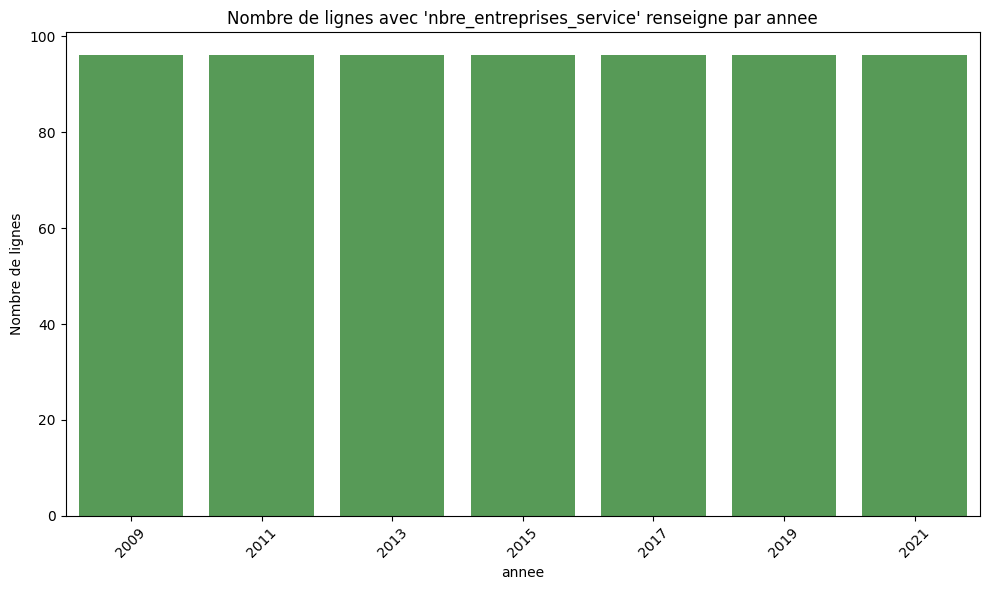

In [31]:

# 1. Nombre de lignes (departements) par annee
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='annee', hue='annee', palette='viridis', legend=False)
plt.title("Nombre de lignes par annee")
plt.xlabel("annee")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.show()


# 2. Top departements
top_dept = df['Code_Dpt'].value_counts()
plt.figure(figsize=(20, 5))
sns.barplot(x=top_dept.index, y=top_dept.values)
plt.xticks(rotation=45)
plt.title("Nombre de ligne par departement")
plt.show()

# 3. Nombre de lignes (nbre_entreprises_agricole) par annee
df_filtered = df[df['nbre_entreprises_agricole'].notna() & (df['nbre_entreprises_agricole'] != 0)]
count_by_year = df_filtered.groupby('annee').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(x='annee', y='count', data=count_by_year, color='green', alpha=0.7)
plt.title("Nombre de lignes avec 'nbre_entreprises_agricole' renseigne par annee")
plt.xlabel("annee")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Nombre de lignes (nbre_entreprises_agricole) par annee
df_filtered = df[df['nbre_entreprises_industrie'].notna() & (df['nbre_entreprises_agricole'] != 0)]
count_by_year = df_filtered.groupby('annee').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(x='annee', y='count', data=count_by_year, color='green', alpha=0.7)
plt.title("Nombre de lignes avec 'nbre_entreprises_industrie' renseigne par annee")
plt.xlabel("annee")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Nombre de lignes (nbre_entreprises_agricole) par annee
df_filtered = df[df['nbre_entreprises_service'].notna() & (df['nbre_entreprises_agricole'] != 0)]
count_by_year = df_filtered.groupby('annee').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(x='annee', y='count', data=count_by_year, color='green', alpha=0.7)
plt.title("Nombre de lignes avec 'nbre_entreprises_service' renseigne par annee")
plt.xlabel("annee")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Toutes les annees sont représentées de manière uniforme

Tous les départements le sont également

Au niveau du nombre d'entreprise, les valeurs manquantes sont toutes en 2021

### Traitement des valeurs manquantes

On va recalculer le nombre d'entreprise en fonction des salariés et de la taille moyenne des entreprises sur les 6 annees renseignées par département

In [32]:
df_filtered = df.loc[(df['annee'] >= 2009) & (df['annee'] <= 2019),['Code_Dpt','annee','nb_salaries_secteur_agricole', 
                                                                 'nb_salaries_secteur_industrie','nb_salaries_secteur_service', 
                                                                 'nbre_entreprises_agricole','nbre_entreprises_industrie','nbre_entreprises_service']].copy()
df_filtered['ratio_agricole'] = df_filtered['nb_salaries_secteur_agricole'] / df_filtered['nbre_entreprises_agricole']
df_filtered['ratio_industrie'] = df_filtered['nb_salaries_secteur_industrie'] / df_filtered['nbre_entreprises_industrie']
df_filtered['ratio_service'] = df_filtered['nb_salaries_secteur_service'] / df_filtered['nbre_entreprises_service']


In [33]:
df_filtered

,Code_Dpt,annee,nb_salaries_secteur_agricole,nb_salaries_secteur_industrie,nb_salaries_secteur_service,nbre_entreprises_agricole,nbre_entreprises_industrie,nbre_entreprises_service,ratio_agricole,ratio_industrie,ratio_service
0,01,2009,5719,68343,141408,3092,6263,15605,1.849612,10.912183,9.061711
1,02,2009,9413,44128,129961,3720,3913,11215,2.530376,11.277281,11.588141
2,03,2009,7372,31537,92422,3325,3011,8474,2.217143,10.473929,10.906538
3,04,2009,3155,10803,44575,1473,2096,6415,2.141887,5.154103,6.948558
4,05,2009,2761,8607,46547,1333,1869,5980,2.071268,4.605136,7.783779
...,...,...,...,...,...,...,...,...,...,...,...
571,91,2019,1589,73151,374151,795,10622,35838,1.998742,6.886744,10.440064
572,92,2019,519,117123,851378,210,7781,35979,2.471429,15.052435,23.663192
573,93,2019,256,81749,505543,154,10691,32003,1.662338,7.646525,15.796738
574,94,2019,295,64534,456869,164,8265,29831,1.798780,7.808106,15.315243


In [34]:
secteurs = ['agricole', 'industrie', 'service']
moyennes_par_secteur = {}  

for secteur in secteurs:
    df_filtered[f'ratio_{secteur}'] = (
        df_filtered[f'nb_salaries_secteur_{secteur}'] /
        df_filtered[f'nbre_entreprises_{secteur}']
    )
    moyennes_par_secteur[secteur] = (
    df_filtered.groupby('Code_Dpt', as_index=False)[f'ratio_{secteur}']
    .mean()
    .rename(columns={f'ratio_{secteur}': f'moyenne_ratio_{secteur}'})
    )

moyennes_combinees = moyennes_par_secteur['agricole']
for secteur in secteurs[1:]: 
    moyennes_combinees = moyennes_combinees.merge(
        moyennes_par_secteur[secteur],
        on='Code_Dpt',
        how='outer'
    )


In [35]:
df_2021 = df[df['annee']==2021].copy()

for secteur in secteurs:
    df_2021 = df_2021.merge(
        moyennes_combinees[['Code_Dpt', f'moyenne_ratio_{secteur}']],
        on='Code_Dpt',
        how='left'
    )
    df_2021[f'nbre_entreprises_{secteur}'] = (
        df_2021[f'nb_salaries_secteur_{secteur}'] /
        df_2021[f'moyenne_ratio_{secteur}']
    ).round()

    df = df.merge(
        df_2021[['Code_Dpt', 'annee', f'nbre_entreprises_{secteur}']],
        on=['Code_Dpt', 'annee'],
        how='left',
        suffixes=('', '_estime')
    )

    df[f'nbre_entreprises_{secteur}'] = df[f'nbre_entreprises_{secteur}_estime'].combine_first(
        df[f'nbre_entreprises_{secteur}']
    )

    df = df.drop(columns=[f'nbre_entreprises_{secteur}_estime'])


Le df est maintenant complet, on va sauvegarder le fichier en data_wip_complet.csv

In [36]:
df

,Code_Dpt,Departement,Region,annee,densite,pop_globale,tranche_age_0-24,tranche_age_25-59,tranche_age_60+,csp1_agriculteurs,...,nb_salaries_secteur_agricole,nb_salaries_secteur_industrie,nb_salaries_secteur_service,nbre_entreprises_agricole,nbre_entreprises_industrie,nbre_entreprises_service,Deblais_gravats,Dechets_verts,Encombrants,Materiaux_recyclables
0,01,Ain,Auvergne-Rhône-Alpes,2009,101.8,588857,188068,281744,119045,4017,...,5719,68343,141408,3092.0,6263.0,15605.0,37593,45013,34729,25405
1,02,Aisne,Hauts-de-France,2009,73.4,539547,170369,249910,119268,5250,...,9413,44128,129961,3720.0,3913.0,11215.0,24380,24539,31593,10542
2,03,Allier,Auvergne-Rhône-Alpes,2009,46.6,342559,86913,152570,103076,6019,...,7372,31537,92422,3325.0,3011.0,8474.0,14374,18612,11932,8564
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,2009,23.0,159510,43500,70222,45788,2136,...,3155,10803,44575,1473.0,2096.0,6415.0,11228,8280,9006,7327
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,2009,24.5,135883,37235,62716,35932,2214,...,2761,8607,46547,1333.0,1869.0,5980.0,8509,6121,7938,10344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,91,Essonne,Île-de-France,2021,728.1,1320900,440758,605802,274340,820,...,1568,73190,383468,826.0,8555.0,31897.0,51321,27508,102448,9548
668,92,Hauts-de-Seine,Île-de-France,2021,9312.1,1639335,505758,800744,332833,168,...,524,118312,878347,236.0,6511.0,35473.0,6436,2378,47739,4943
669,93,Seine-Saint-Denis,Île-de-France,2021,7064.6,1671620,591433,795744,284443,102,...,292,82379,521461,157.0,8064.0,29220.0,41319,6326,50110,8484
670,94,Val-de-Marne,Île-de-France,2021,5776.3,1416897,457743,670809,288345,116,...,426,64235,464656,199.0,6577.0,27190.0,17873,3524,19542,4616


In [37]:
# df.to_csv('../data/data_wip_complet.csv',index=False,encoding='utf-8-sig')

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False, encoding="utf-8-sig")

# Upload S3
s3 = boto3.client("s3", region_name="eu-west-3")
bucket_name = "geodechet"
key = "data/data_wip_complet.csv"  # chemin dans S3

s3.put_object(
    Bucket=bucket_name,
    Key=key,
    Body=csv_buffer.getvalue(),
    ContentType="text/csv",
)

{'ResponseMetadata': {'RequestId': '022R93BSS3PEAJN8',
  'HostId': '6KdC5QKlzpDrOlwHiOD26+GlYNx6vpAC0/r8FaLDAwcLM0maxQdx8OxYIwY5rsq+GUJmBN+Ro8nYPc4S+rPKGT0hdjPpmS6F',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': '6KdC5QKlzpDrOlwHiOD26+GlYNx6vpAC0/r8FaLDAwcLM0maxQdx8OxYIwY5rsq+GUJmBN+Ro8nYPc4S+rPKGT0hdjPpmS6F',
   'x-amz-request-id': '022R93BSS3PEAJN8',
   'date': 'Fri, 14 Nov 2025 17:29:25 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"57261af55cf2959b339c4513fc897f98"',
   'x-amz-checksum-crc32': 'HwFnyg==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"57261af55cf2959b339c4513fc897f98"',
 'ChecksumCRC32': 'HwFnyg==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

# Partie2 - Etude de la population

In [38]:
fig_region_pop_insee = px.bar(df, x='Region', y='pop_globale',
                                    animation_frame='annee', title='Population par Annee et par region',
                                    color='Region',hover_data=['Departement'])
fig_region_pop_insee.show()

In [39]:
df_trage = df.groupby(['annee'])[['tranche_age_0-24','tranche_age_25-59','tranche_age_60+']].sum().reset_index()
fig_trage_annee = px.bar(df_trage, x='annee', y='tranche_age_0-24', title='Population de la tranche d\'âge de 0 à 24 ans')
fig_trage_annee.update_layout(yaxis_range=[19000000, 19400000])
fig_trage_annee.show()

In [40]:
fig_trage_annee = px.bar(df_trage, x='annee', y='tranche_age_25-59', title='Population de la tranche d\'âge de 25 à 59 ans')
fig_trage_annee.update_layout(yaxis_range=[28700000, 29200000])
fig_trage_annee.show()

In [41]:
fig_trage_annee = px.bar(df_trage, x='annee', y='tranche_age_60+', title='Population de la tranche d\'âge de 60 ans et plus')
fig_trage_annee.update_layout(yaxis_range=[13800000, 18000000])
fig_trage_annee.show()

On remarque une population vieillissante.

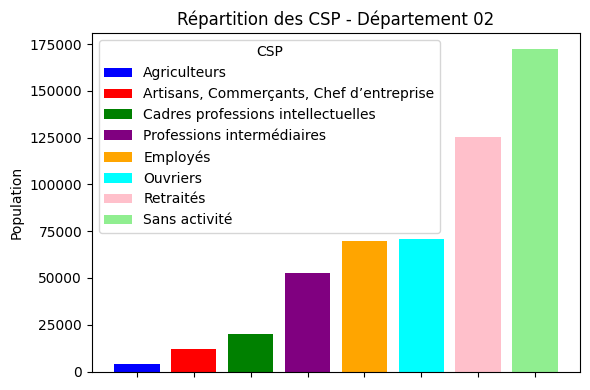

In [42]:
df_02 = df[(df["Code_Dpt"] == "02") & (df["annee"] == 2021)].copy()

csp_vars = [
    "csp1_agriculteurs",
    "csp2_artisans_commercant_chef_entreprises",
    "csp3_cadres_professions_intellectuelles",
    "csp4_professions_intermediaires",
    "csp5_employes",
    "csp6_ouvriers",
    "csp7_retraites",
    "csp8_sans_activite"
]
csp_labels = [
    "Agriculteurs",
    "Artisans, Commerçants, Chef d’entreprise",
    "Cadres professions intellectuelles",
    "Professions intermédiaires",
    "Employés",
    "Ouvriers",
    "Retraités",
    "Sans activité"
]
csp_colors = [
    "blue", "red", "green", "purple",
    "orange", "cyan", "pink", "lightgreen"
]

values = df_02[csp_vars].values[0]


fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    x=csp_labels,
    height=values,
    color=csp_colors
)

# Mise en forme
ax.set_ylabel("Population")
ax.set_xticklabels([])
ax.set_title("Répartition des CSP - Département 02")

# Légende
ax.legend(bars, csp_labels, title="CSP")

plt.tight_layout()
plt.show()


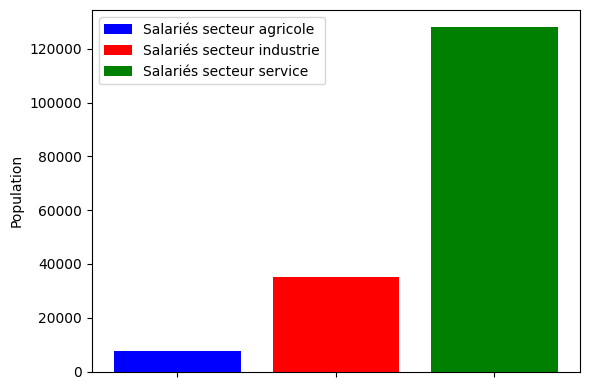

In [43]:
sec_vars = [
    "nb_salaries_secteur_agricole",
    "nb_salaries_secteur_industrie",
    "nb_salaries_secteur_service"
]
sec_labels = [
    "Salariés secteur agricole",
    "Salariés secteur industrie",
    "Salariés secteur service"
]
sec_colors = [
    "blue", "red", "green"
]

values = df_02[sec_vars].values[0]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    x=sec_labels,
    height=values,
    color=sec_colors
)

# Mise en forme
ax.set_ylabel("Population")
ax.set_xticklabels([])

# Légende
ax.legend(bars, sec_labels)

plt.tight_layout()
plt.show()


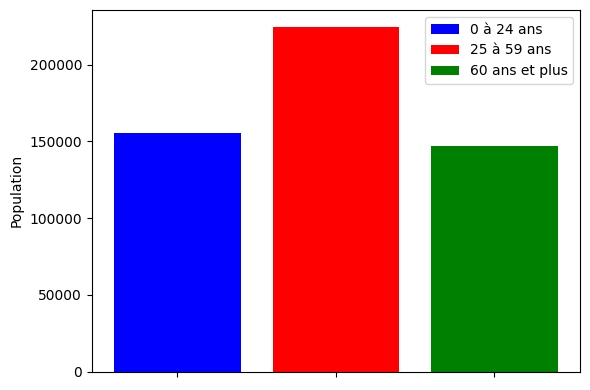

In [44]:
trage_vars = [
    "tranche_age_0-24",
    "tranche_age_25-59",
    "tranche_age_60+"
]

trage_labels = [
    "0 à 24 ans",
    "25 à 59 ans",
    "60 ans et plus"
]
trage_colors = [
    "blue", "red", "green"
]

values = df_02[trage_vars].values[0]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    x=trage_labels,
    height=values,
    color=trage_colors
)

# Mise en forme
ax.set_ylabel("Population")
ax.set_xticklabels([])

# Légende
ax.legend(bars, trage_labels)

plt.tight_layout()
plt.show()


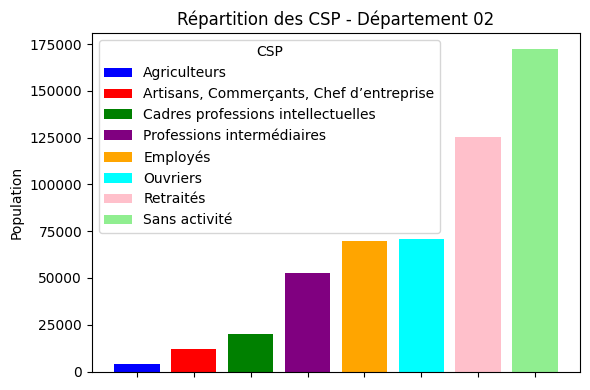

In [45]:
df_02 = df[(df["Region"] == "Hauts-de-France") & (df["annee"] == 2021)].copy()

csp_vars = [
    "csp1_agriculteurs",
    "csp2_artisans_commercant_chef_entreprises",
    "csp3_cadres_professions_intellectuelles",
    "csp4_professions_intermediaires",
    "csp5_employes",
    "csp6_ouvriers",
    "csp7_retraites",
    "csp8_sans_activite"
]
csp_labels = [
    "Agriculteurs",
    "Artisans, Commerçants, Chef d’entreprise",
    "Cadres professions intellectuelles",
    "Professions intermédiaires",
    "Employés",
    "Ouvriers",
    "Retraités",
    "Sans activité"
]
csp_colors = [
    "blue", "red", "green", "purple",
    "orange", "cyan", "pink", "lightgreen"
]

values = df_02[csp_vars].values[0]


fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    x=csp_labels,
    height=values,
    color=csp_colors
)

# Mise en forme
ax.set_ylabel("Population")
ax.set_xticklabels([])
ax.set_title("Répartition des CSP - Département 02")

# Légende
ax.legend(bars, csp_labels, title="CSP")

plt.tight_layout()
plt.show()

# Partie 3 - Etude des déchets

In [46]:
df_reduit = df[['annee','Region','Departement','Deblais_gravats','Dechets_verts','Encombrants','Materiaux_recyclables']]
df_reduit_annee = df.groupby('annee')[['Deblais_gravats','Dechets_verts','Encombrants','Materiaux_recyclables']].sum().reset_index()
df_dechet = df_reduit_annee.melt(
    id_vars=['annee'],
    var_name='type_dechet',
    value_name='tonnes'
)
df_dechet['type_dechet'] = df_dechet['type_dechet'].str.replace('_', ' ')


In [47]:
fig_dechet = px.bar(df_dechet, x='annee', y='tonnes',
                                    title='Tonnage de déchets par année',
                                    color='type_dechet',hover_data=['type_dechet'])
fig_dechet.show()

c:\Users\franc\anaconda3\envs\env_geodechet\Lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [48]:
df_reduit_region_annee = df.groupby(['annee','Region'])[['Deblais_gravats','Dechets_verts','Encombrants','Materiaux_recyclables']].sum().reset_index()
df_dechet = df_reduit_region_annee.melt(
    id_vars=['annee','Region'],
    var_name='type_dechet',
    value_name='tonnes'
)
df_dechet['type_dechet'] = df_dechet['type_dechet'].str.replace('_', ' ')
fig_region_annee = px.bar(df_dechet, x='Region', y='tonnes',
                                    animation_frame='annee', title='Tonnes de déchet par région et par type de déchet',
                                    color='type_dechet',hover_data=['type_dechet'])
fig_region_annee.show()


In [49]:
df_reduit_region_annee_pop = df.groupby(['annee','Region'])[['Deblais_gravats','Dechets_verts','Encombrants','Materiaux_recyclables','pop_globale']].sum().reset_index()
df_dechet = df_reduit_region_annee_pop.melt(
    id_vars=['annee','Region','pop_globale'],
    var_name='type_dechet',
    value_name='tonnes'
)
df_dechet['kg_par_hab']=df_dechet['tonnes']*1000/df_dechet['pop_globale']

df_dechet['type_dechet'] = df_dechet['type_dechet'].str.replace('_', ' ')
fig_region_annee = px.bar(df_dechet, x='Region', y='kg_par_hab',
                                    animation_frame='annee', title='Poids des déchets par habitant et par région',
                                    color='type_dechet',hover_data=['type_dechet'])
fig_region_annee.show()


### Table de corrélation des déchets

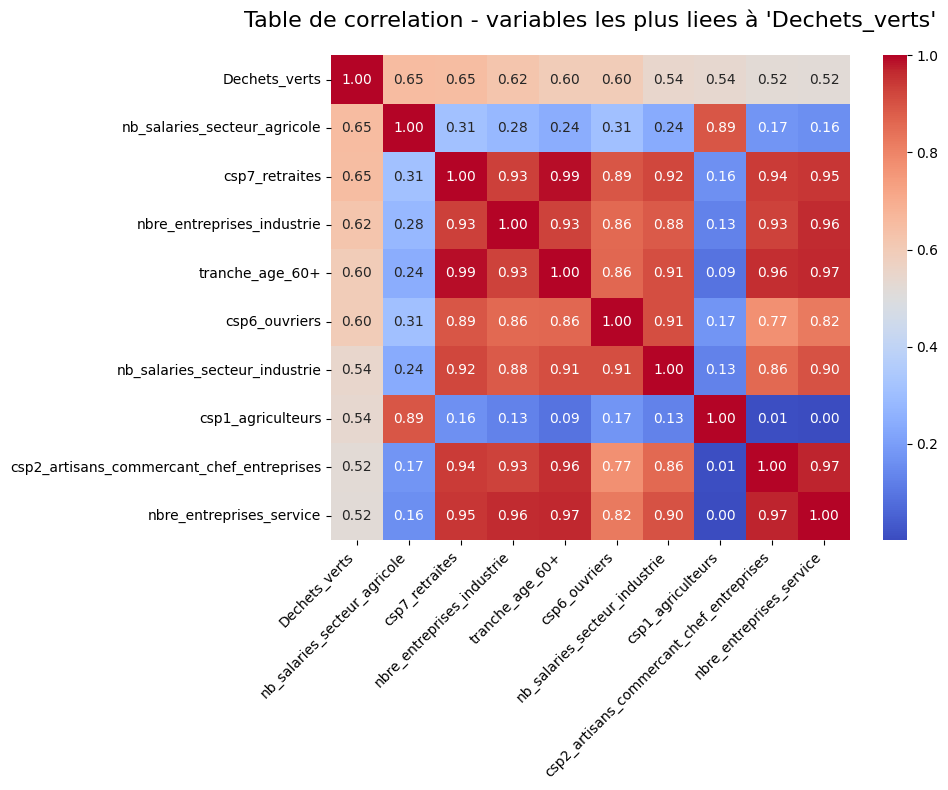

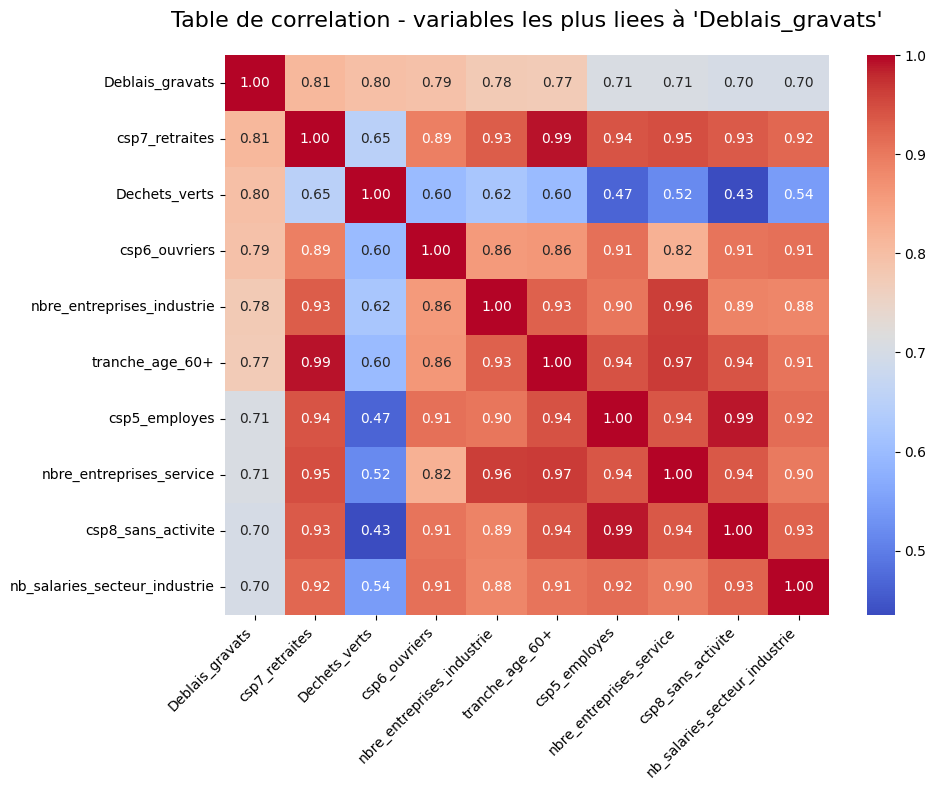

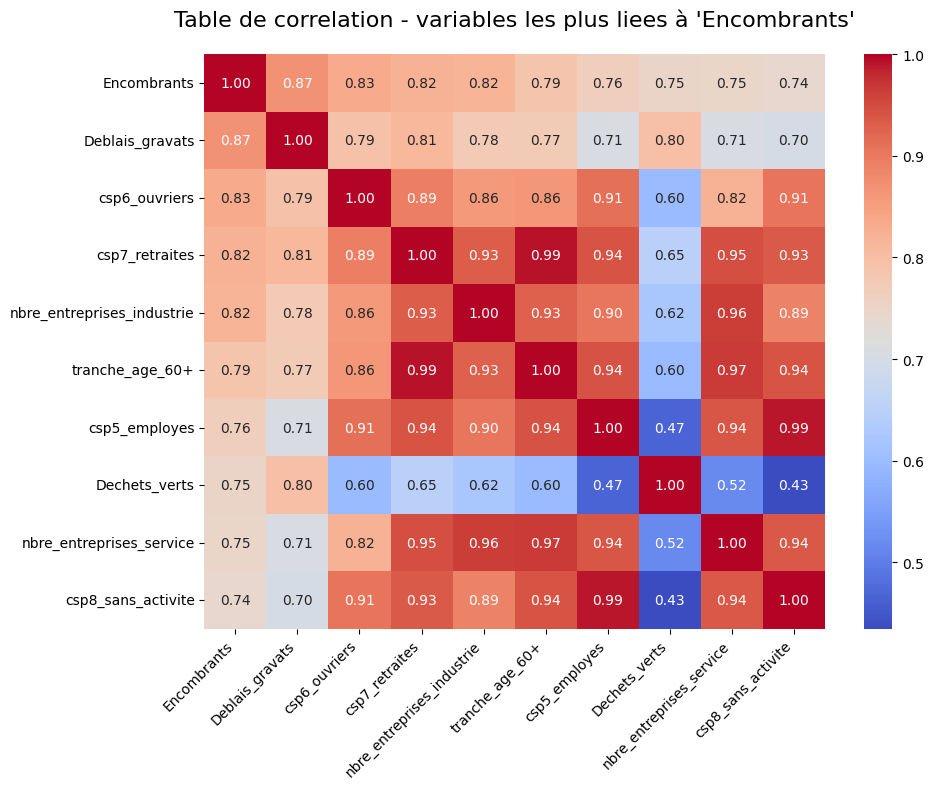

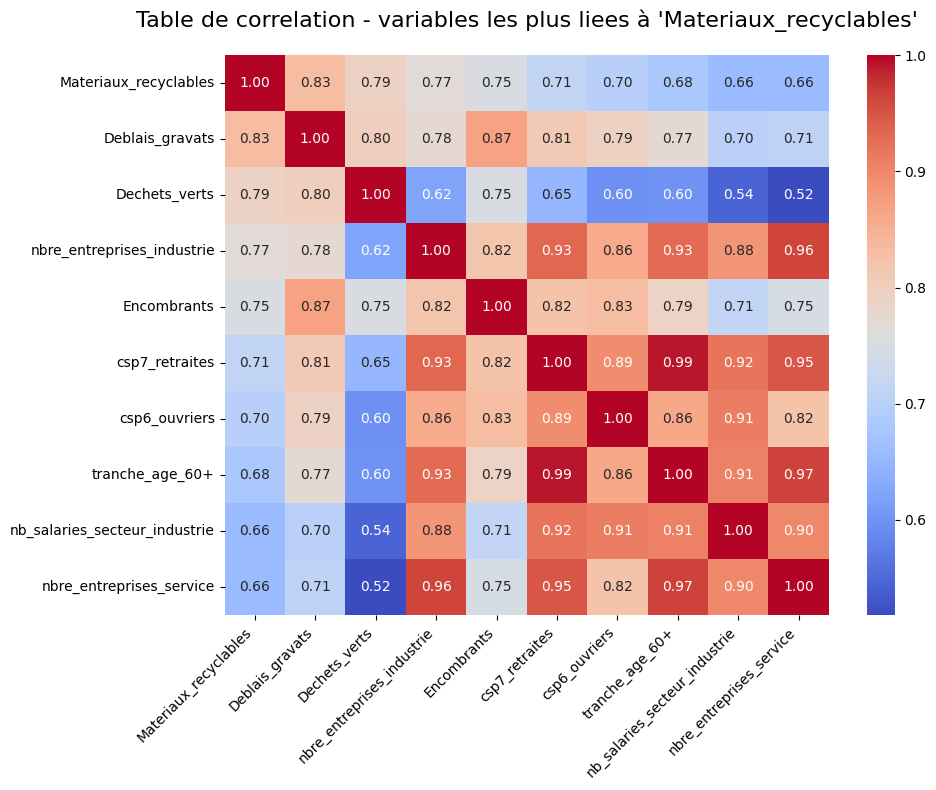

In [50]:
targets=['Dechets_verts', 'Deblais_gravats','Encombrants','Materiaux_recyclables']

# Supprimer typologie des dechets
liste_sup = ['Deblais_gravats', 'Dechets_verts', 'Encombrants', 'Materiaux_recyclables']
# # Initialiser une liste pour stocker les resultats
results = []

for target in targets :
    correlation =df.corr(numeric_only=True)
    correlation_target = correlation[target].sort_values(ascending=False)
    liste_sup = [col for col in liste_sup if col != target]
    correlation_clean = correlation_target.drop(liste_sup)
    top_10 = correlation_clean.head(10)

    # Stocker les resultats
    for feature, corr_value in top_10.items():
        results.append({'Target': target, 'Feature': feature, 'Correlation': corr_value})

    # visualisation
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[top_10.index].corr(), annot=True, fmt=".2f", cmap="coolwarm")

    plt.title(f"Table de correlation - variables les plus liees à '{target}'", 

          fontsize=16, 
          loc='center', 
          pad=20)  # pad = espace entre le titre et la heatmap

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [51]:
# Retirer les targets de la colonne Feature
df_results = pd.DataFrame(results)
df_results = df_results[~df_results['Feature'].isin(targets)] # ~inverse /  retourne un booleen True pour les lignes où 'Feature' est dans targets.

# Affichage
df_results

,Target,Feature,Correlation
1,Dechets_verts,nb_salaries_secteur_agricole,0.654753
2,Dechets_verts,csp7_retraites,0.650392
3,Dechets_verts,nbre_entreprises_industrie,0.622296
4,Dechets_verts,tranche_age_60+,0.597513
5,Dechets_verts,csp6_ouvriers,0.596659
6,Dechets_verts,nb_salaries_secteur_industrie,0.544265
7,Dechets_verts,csp1_agriculteurs,0.538783
8,Dechets_verts,csp2_artisans_commercant_chef_entreprises,0.521712
9,Dechets_verts,nbre_entreprises_service,0.517736
11,Deblais_gravats,csp7_retraites,0.810623


In [52]:
df_pivot = df_results.pivot_table(
    index='Feature',       # Ce sera l'index (les lignes du tableau)
    columns='Target',      # Les colonnes seront les targets
    values='Correlation',  # Les valeurs du tableau
    aggfunc='first'        # Pas necessaire ici, mais utile si doublons
).reset_index()
df_pivot

Target,Feature,Deblais_gravats,Dechets_verts,Encombrants,Materiaux_recyclables
0,csp1_agriculteurs,NaN,0.538783,NaN,NaN
1,csp2_artisans_commercant_chef_entreprises,NaN,0.521712,NaN,NaN
2,csp5_employes,0.706904,NaN,0.764932,NaN
3,csp6_ouvriers,0.794049,0.596659,0.832255,0.697824
4,csp7_retraites,0.810623,0.650392,0.822163,0.713500
5,csp8_sans_activite,0.701722,NaN,0.740307,NaN
6,nb_salaries_secteur_agricole,NaN,0.654753,NaN,NaN
7,nb_salaries_secteur_industrie,0.700953,0.544265,NaN,0.656966
8,nbre_entreprises_industrie,0.775066,0.622296,0.817550,0.767735
9,nbre_entreprises_service,0.706662,0.517736,0.746932,0.656738


In [53]:
df_pivot_2=df_pivot.dropna()
df_pivot_2

Target,Feature,Deblais_gravats,Dechets_verts,Encombrants,Materiaux_recyclables
3,csp6_ouvriers,0.794049,0.596659,0.832255,0.697824
4,csp7_retraites,0.810623,0.650392,0.822163,0.713500
8,nbre_entreprises_industrie,0.775066,0.622296,0.817550,0.767735
9,nbre_entreprises_service,0.706662,0.517736,0.746932,0.656738
10,tranche_age_60+,0.773764,0.597513,0.790077,0.679944


In [54]:
# Transformer le DataFrame en format long
df_melted = df_pivot_2.melt(id_vars=['Feature'], var_name='Target', value_name='Correlation')

# Creer le graphique en barres groupees

color_map = { 
    "Dechets_verts": "green",
    "Deblais_gravats": "orange",
    "Materiaux_recyclables": "yellow",
    "Encombrants": "#8B008B",
}
fig = px.bar(df_melted, x='Feature', y='Correlation', color='Target', barmode='group',
             color_discrete_map=color_map, 
             title='Top 5 des correlations des Features sur les Targets',
             labels={'Correlation': 'Valeur de Correlation', 'Feature': 'Caracteristique'},
             width=1000)

# Afficher le graphique
fig.show()

c:\Users\franc\anaconda3\envs\env_geodechet\Lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

